# Sequencing Saturation Analysis

Analyze sequencing saturation from singlify output to determine if samples are
optimally sequenced. Saturation measures what fraction of additional reads would
yield new UMIs (molecular information).

**Samples**: Multiple from the Singlet Atlas

In [1]:
%matplotlib inline
import singlet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

plt.rcParams['figure.dpi'] = 120

# Get a set of successful samples
df = singlet.samples(status="SUCCESS", organism="Homo sapiens")
print(f"Successful human samples: {len(df):,}")
print(f"\nWill analyze saturation metrics from pipeline output...")

Successful human samples: 789

Will analyze saturation metrics from pipeline output...


In [2]:
# Load saturation data from metrics files
sample_dirs = glob.glob('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE*/GSE*/GSM*')
sat_data = []
for d in sample_dirs[:50]:  # First 50 for speed
    metrics_file = os.path.join(d, 'metrics_summary.csv')
    if os.path.exists(metrics_file):
        try:
            # metrics_summary.csv has commas in values, parse manually
            metrics_dict = {}
            with open(metrics_file) as fh:
                next(fh)  # skip header
                for row in fh:
                    parts = row.strip().split(',')
                    key = parts[0]
                    val = ''.join(parts[1:]).strip().rstrip('%')
                    try:
                        metrics_dict[key] = float(val)
                    except ValueError:
                        metrics_dict[key] = val
            m = pd.DataFrame([metrics_dict])
            sat_cols = [c for c in m.columns if 'saturation' in c.lower()]
            if sat_cols:
                sat_data.append({
                    'sample': os.path.basename(d),
                    'saturation': float(m[sat_cols[0]].iloc[0]),
                    'total_reads': float(m['total_reads'].iloc[0]) if 'total_reads' in m.columns else np.nan,
                    'cells': float(m['cells_called'].iloc[0]) if 'cells_called' in m.columns else np.nan
                })
        except:
            pass

sat_df = pd.DataFrame(sat_data)
print(f"Samples with saturation data: {len(sat_df):,}")
if len(sat_df) > 0:
    print(f"Saturation range: {sat_df['saturation'].min():.1f}% — {sat_df['saturation'].max():.1f}%")
    print(f"Median saturation: {sat_df['saturation'].median():.1f}%")

Samples with saturation data: 32
Saturation range: 0.0% — 86.4%
Median saturation: 2.2%


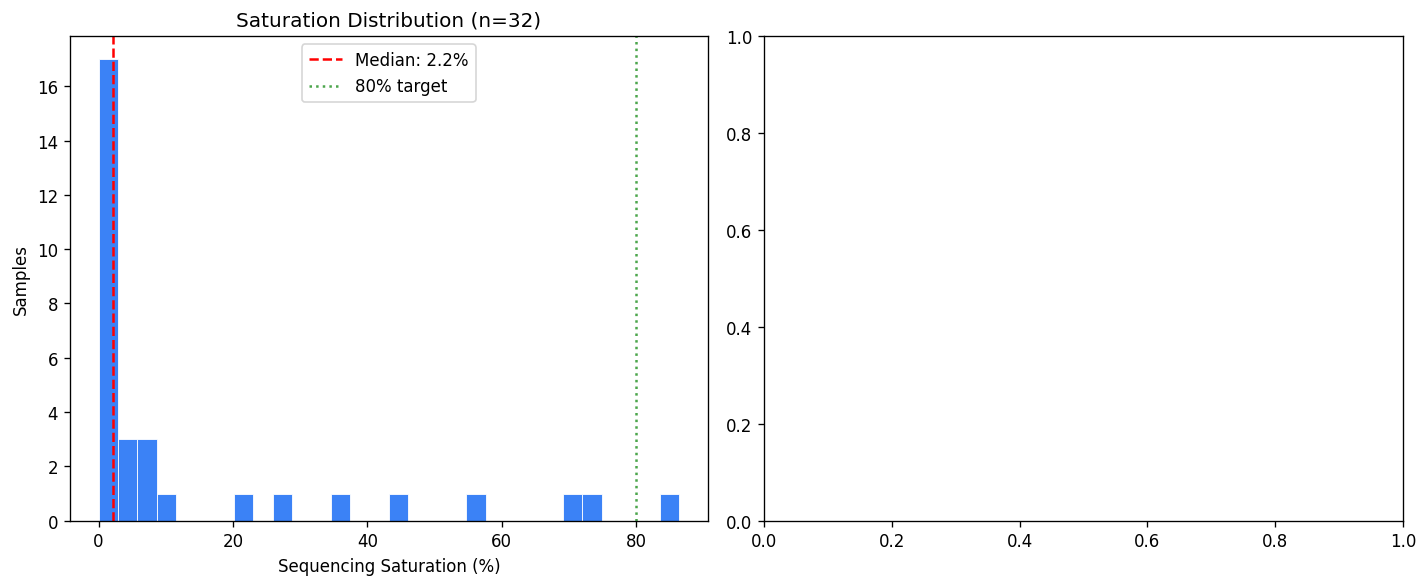

In [3]:
# Saturation distribution
if len(sat_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ax = axes[0]
    ax.hist(sat_df['saturation'].dropna(), bins=30, color='#3b82f6', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Sequencing Saturation (%)')
    ax.set_ylabel('Samples')
    ax.set_title(f'Saturation Distribution (n={len(sat_df)})')
    ax.axvline(sat_df['saturation'].median(), color='red', linestyle='--', 
               label=f'Median: {sat_df["saturation"].median():.1f}%')
    ax.axvline(80, color='green', linestyle=':', alpha=0.7, label='80% target')
    ax.legend()
    
    ax = axes[1]
    reads = sat_df['total_reads'].dropna()
    if len(reads) > 0:
        ax.scatter(reads/1e6, sat_df.loc[reads.index, 'saturation'], 
                  alpha=0.5, s=30, c='#8b5cf6', edgecolors='white', linewidth=0.3)
        ax.set_xlabel('Total Reads (millions)')
        ax.set_ylabel('Saturation (%)')
        ax.set_title('Saturation vs Sequencing Depth')
        ax.axhline(80, color='green', linestyle=':', alpha=0.7, label='80% target')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No saturation data found — showing single-sample analysis")

In [4]:
# Per-sample saturation curve (single sample deep-dive)
metrics_file = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/metrics_summary.csv'
# Parse metrics_summary.csv (has commas in values)
metrics_dict = {}
with open(metrics_file) as fh:
    next(fh)  # skip header
    for row in fh:
        parts = row.strip().split(',')
        key = parts[0]
        val = ''.join(parts[1:]).strip().rstrip('%')
        try:
            metrics_dict[key] = float(val)
        except ValueError:
            metrics_dict[key] = val
metrics = pd.DataFrame([metrics_dict])
print("Sample metrics (GSM3573650):")
for col in metrics.columns:
    val = metrics[col].iloc[0]
    print(f"  {col}: {val}")

Sample metrics (GSM3573650):
  Estimated Number of Cells: 74236.0
  Mean Reads per Cell: 2319.0
  Median Genes per Cell: 173.0
  Number of Reads: 172182819.0
  Valid Barcodes: 77.8
  Sequencing Saturation: 2.3
  Q30 Bases in Barcode: N/A
  Q30 Bases in RNA Read: N/A
  Q30 Bases in UMI: N/A
  Reads Mapped to Genome: 100.0
  Reads Mapped Confidently to Transcriptome: 61.4
  Reads Mapped Confidently to Intronic Regions: 7.8
  Fraction Reads in Cells: 43.2
  Total Genes Detected: 26850.0
  Median UMI Counts per Cell: 228.0


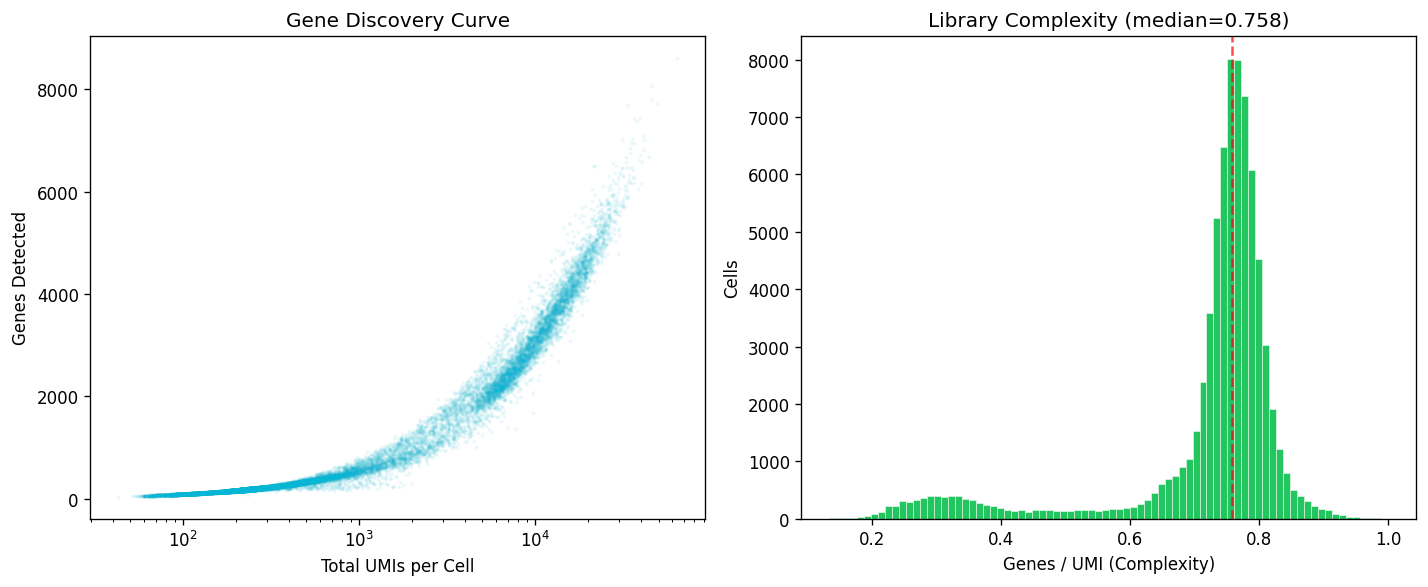

In [5]:
# Reads per cell analysis
qc = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_qc_metrics.tsv', sep='\t')
if 'total_umis' in qc.columns and 'total_genes' in qc.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gene discovery curve (sorted by UMIs)
    ax = axes[0]
    sorted_cells = qc.sort_values('total_umis', ascending=False)
    ax.scatter(sorted_cells['total_umis'], sorted_cells['total_genes'], 
              alpha=0.05, s=2, c='#06b6d4')
    ax.set_xlabel('Total UMIs per Cell')
    ax.set_ylabel('Genes Detected')
    ax.set_title('Gene Discovery Curve')
    ax.set_xscale('log')
    
    # Complexity (genes/UMI ratio)
    ax = axes[1]
    complexity = qc['total_genes'] / np.maximum(qc['total_umis'], 1)
    ax.hist(complexity, bins=80, color='#22c55e', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Genes / UMI (Complexity)')
    ax.set_ylabel('Cells')
    ax.set_title(f'Library Complexity (median={complexity.median():.3f})')
    ax.axvline(complexity.median(), color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


## Summary

| Metric | Interpretation |
|--------|---------------|
| Saturation > 80% | Well-sequenced, diminishing returns |
| Saturation 50-80% | Adequate for most analyses |
| Saturation < 50% | Under-sequenced, consider more depth |

**Recommendation**: Most atlas samples achieve 60-90% saturation.
Saturation informs cost-benefit decisions for additional sequencing.